In [ ]:
# ==============================================================================
# SCRIPT DIDÁCTICO: ANÁLISIS ESPACIAL Y TEMPORAL
# Objetivo: Extraer series, calcular balance hídrico y generar mapas.
# Nivel: Principiante / Intermedio.
# ==============================================================================

import ee
from google.colab import drive
import geopandas as gpd
import geemap
import pandas as pd
import numpy as np
import time
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

In [ ]:
# ------------------------------------------------------------------------------
# 1. AUTENTICACIÓN E INICIALIZACIÓN
# ------------------------------------------------------------------------------
try:
    ee.Authenticate()
    ee.Initialize(project='lucasvituri') # Asegúrate de que el proyecto sea correcto
    print("Earth Engine inicializado con éxito.")
except Exception as e:
    print(f"Error de inicialización: {e}")

drive.mount('/content/drive')

Earth Engine inicializado con éxito.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ------------------------------------------------------------------------------
# 2. PROCESAMIENTO ESPACIAL DEL SHAPEFILE (Manejo de Cuencas y Subcuencas)
# ------------------------------------------------------------------------------
print("\nDescomprimiendo y cargando el Shapefile...")

# Ruta original de tu ZIP en Google Drive
ruta_zip = '/content/drive/MyDrive/GEOHIDRO_T4/SubSubCuencas.zip'
carpeta_extraccion = '/content/temp_shapefile'

# A. Descomprimir el archivo ZIP de forma segura
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(carpeta_extraccion)

# B. Buscar automáticamente el archivo .shp
ruta_shp_extraido = None
for root, dirs, files in os.walk(carpeta_extraccion):
    for file in files:
        if file.endswith('.shp'):
            ruta_shp_extraido = os.path.join(root, file)
            break

if ruta_shp_extraido is None:
    raise FileNotFoundError("¡No se encontró ningún archivo .shp dentro del ZIP!")

# C. Leer el shapefile descomprimido localmente con GeoPandas
gdf = gpd.read_file(ruta_shp_extraido)

# D. FILTRADO DIDÁCTICO:
cuenca_objetivo = '054'
columna_cuenca = 'COD_CUEN'

gdf_cuenca = gdf[gdf[columna_cuenca] == cuenca_objetivo]

if gdf_cuenca.empty:
    print(f"¡ADVERTENCIA! No se encontraron geometrías para la cuenca {cuenca_objetivo}.")
else:
    nombre_cuenca = gdf_cuenca['NOM_CUEN'].iloc[0] if 'NOM_CUEN' in gdf_cuenca.columns else cuenca_objetivo
    print(f"Se filtraron {len(gdf_cuenca)} subcuencas para: {nombre_cuenca}.")

gdf_filtrado = gdf_cuenca

# E. Convertir a Earth Engine
aoi = geemap.geopandas_to_ee(gdf_filtrado)
geom_aoi = aoi.geometry()

print("Geometría lista para Earth Engine.")


Descomprimiendo y cargando el Shapefile...
Se filtraron 23 subcuencas para: 054.
Geometría lista para Earth Engine.


In [ ]:
# ------------------------------------------------------------------------------
# 3. EXTRACCIÓN DE LA SERIE TEMPORAL (P y ET)
# ------------------------------------------------------------------------------
a_o_inicio = 2003 # Comenzamos el análisis en 2000
a_o_fin = 2026 # Hasta 2025
a_os = range(a_o_inicio, a_o_fin + 1)
meses = range(1, 13)

print("\nIniciando extracción de serie temporal (Precipitación y Evapotranspiración)...")
lista_features = []

for a_o in a_os:
    for mes in meses:
        start_date = ee.Date.fromYMD(a_o, mes, 1)
        end_date = start_date.advance(1, 'month')

        # 1. Colección CHIRPS (Precipitación)
        chirps_mes = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").filterDate(start_date, end_date)

        # 2. Colección MODIS Gap-Filled (Evapotranspiración Real)
        tc_mes = ee.ImageCollection("MODIS/061/MOD16A2GF").filterDate(start_date, end_date)

        # 3. Colección GLDAS (Nieve - SWE)
        nv_mes = ee.ImageCollection("NASA/GLDAS/V022/CLSM/G025/DA1D").filterDate(start_date, end_date)

        # Extracción P (Suma de los días del mes)
        p_media = ee.Algorithms.If(
            chirps_mes.size().gt(0),
            chirps_mes.sum().reduceRegion(
                reducer=ee.Reducer.mean(), geometry=geom_aoi, scale=5566, maxPixels=1e9
            ).get('precipitation'),
            ee.Number(-9999)
        )

        # Extracción ET
        et_media = ee.Algorithms.If(
            tc_mes.size().gt(0),
            tc_mes.select('ET').sum().multiply(0.1).reduceRegion(
                reducer=ee.Reducer.mean(), geometry=geom_aoi, scale=500, maxPixels=1e9
            ).get('ET'),
            ee.Number(-9999)
        )

        # Extracción Nieve (SWE)
        nieve_media = ee.Algorithms.If(
            nv_mes.size().gt(0),
            nv_mes.select('SWE_tavg').mean().reduceRegion(
                reducer=ee.Reducer.mean(), geometry=geom_aoi, scale=27830, maxPixels=1e9
            ).get('SWE_tavg'),
            ee.Number(-9999)
        )

        feat = ee.Feature(None, {
            'Fecha': f"{a_o}-{mes:02d}",
            'a_o': a_o,
            'Mes': mes,
            'P_mm': p_media,
            'ET_mm': et_media,
            'SWE_tavg': nieve_media
        })
        lista_features.append(feat)

fc_temporal = ee.FeatureCollection(lista_features)
datos_descargados = fc_temporal.getInfo()

# Transformar JSON a Pandas DataFrame
tabla_datos = []
for f in datos_descargados['features']:
    props = f['properties']
    tabla_datos.append({
        'Fecha': props.get('Fecha'),
        'a_o': props.get('a_o'),
        'Mes': props.get('Mes'),
        'P_mm': props.get('P_mm'),
        'ET_mm': props.get('ET_mm'),
        'SWE_tavg': props.get('SWE_tavg')
    })

df_serie = pd.DataFrame(tabla_datos)

# Limpiar valores faltantes
df_serie['P_mm'] = df_serie['P_mm'].replace(-9999, np.nan).round(2)
df_serie['ET_mm'] = df_serie['ET_mm'].replace(-9999, np.nan).round(2)
df_serie['SWE_tavg'] = df_serie['SWE_tavg'].replace(-9999, np.nan).round(2)

# Calcular Balance
df_serie['Balance_mm'] = df_serie['P_mm'] - df_serie['ET_mm']

ruta_csv = f'/content/drive/MyDrive/GEOHIDRO_T4/Serie_Temporal_P_ET_{cuenca_objetivo}.csv'
df_serie.to_csv(ruta_csv, index=False)
print(f"Tabla guardada en: {ruta_csv}")


Iniciando extracción de serie temporal (Precipitación y Evapotranspiración)...
Tabla guardada en: /content/drive/MyDrive/GEOHIDRO_T4/Serie_Temporal_P_ET_054.csv


In [ ]:
# ------------------------------------------------------------------------------
# 4. ANÁLISIS ESTADÍSTICO EN PANDAS
# ------------------------------------------------------------------------------
print("\nRealizando análisis estadístico anual (P, ET y Balance)...")

# Agrupación anual (Ignoramos años incompletos si los hay por rezago de datos)
df_anual = df_serie.groupby('a_o').sum(min_count=12).reset_index()

# Filtrar años donde P_mm no es NaN antes de buscar min/max
df_anual_cleaned = df_anual.dropna(subset=['P_mm', 'ET_mm']) # Also consider ET_mm for robust balance calculation

if not df_anual_cleaned.empty:
    ano_mas_seco = int(df_anual_cleaned.loc[df_anual_cleaned['P_mm'].idxmin(), 'a_o'])
    ano_mas_humedo = int(df_anual_cleaned.loc[df_anual_cleaned['P_mm'].idxmax(), 'a_o'])

    print(f"-> Año más SECO detectado: {ano_mas_seco} (P: {df_anual_cleaned['P_mm'].min():.1f} mm)")
    print(f"-> Año más HÚMEDO detectado: {ano_mas_humedo} (P: {df_anual_cleaned['P_mm'].max():.1f} mm)")

    media_antes_2010 = df_anual_cleaned[df_anual_cleaned['a_o'] <= 2010]['P_mm'].mean()
    media_despues_2010 = df_anual_cleaned[df_anual_cleaned['a_o'] > 2010]['P_mm'].mean()

    if not pd.isna(media_antes_2010) and media_antes_2010 != 0: # Evitar división por cero o NaN
        var_pct_p = ((media_despues_2010 - media_antes_2010) / media_antes_2010) * 100
        print(f"\n--- Resumen Climático de la Cuenca ---")
        print(f"Variación Lluvia (>2010 vs <=2010): {var_pct_p:.1f}%")
    else:
        print("\n--- Resumen Climático de la Cuenca ---")
        print("No hay suficientes datos válidos de precipitación antes o después de 2010 para calcular la variación.")
else:
    print("No hay datos anuales válidos de precipitación y/o evapotranspiración para realizar el análisis estadístico.")


Realizando análisis estadístico anual (P, ET y Balance)...
-> Año más SECO detectado: 2021 (P: 214.1 mm)
-> Año más HÚMEDO detectado: 2024 (P: 564.3 mm)

--- Resumen Climático de la Cuenca ---
Variación Lluvia (>2010 vs <=2010): -17.6%


In [ ]:
# ------------------------------------------------------------------------------
# 5. GENERACIÓN DE MAPAS ESPACIALES EN LA NUBE (TIFFs)
# ------------------------------------------------------------------------------
print("\nGenerando mapas en Earth Engine y enviando a Google Drive...")

def exportar_mapa(imagen, nombre_archivo, scale=5566):
    bounds = geom_aoi.bounds().coordinates().get(0).getInfo()
    task = ee.batch.Export.image.toDrive(
        image=imagen.clip(geom_aoi),
        description=nombre_archivo,
        folder='GEOHIDRO_T4',
        scale=scale,
        region=bounds,
        maxPixels=1e10
    )
    task.start()

# Mapas de P (Existentes)
img_seco = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").filter(ee.Filter.calendarRange(ano_mas_seco, ano_mas_seco, 'year')).sum()
img_humedo = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").filter(ee.Filter.calendarRange(ano_mas_humedo, ano_mas_humedo, 'year')).sum()

exportar_mapa(img_seco, f'CHIRPS_Ano_Seco_{ano_mas_seco}')
exportar_mapa(img_humedo, f'CHIRPS_Ano_Humedo_{ano_mas_humedo}')

# MEJORA 3: Mapa de Balance Hídrico Medio Anual (P - ET)
num_anos_completos = a_o_fin - a_o_inicio + 1
rango_ini = f'{a_o_inicio}-01-01'
rango_fin = f'{a_o_fin}-12-31'

p_mean_annual = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY") \
                  .filterDate(rango_ini, rango_fin) \
                  .sum().divide(num_anos_completos)

# Calculamos el promedio anual de ET con MODIS
et_mean_annual = ee.ImageCollection("MODIS/061/MOD16A2GF") \
                   .filterDate(rango_ini, rango_fin) \
                   .select('ET').sum().multiply(0.1).divide(num_anos_completos)

# Promedio anual nieve
nv_mean_annual = ee.ImageCollection("NASA/GLDAS/V022/CLSM/G025/DA1D") \
                   .filterDate(rango_ini, rango_fin) \
                   .select('SWE_tavg').mean().divide(num_anos_completos)
# Resta espacial
img_balance = p_mean_annual.subtract(et_mean_annual)
exportar_mapa(img_balance, f'Balance_Hidrico_Medio_Anual_{cuenca_objetivo}', scale=500) # Resolución nativa MODIS

exportar_mapa(nv_mean_annual, f'Nieve_Medio_Anual_{cuenca_objetivo}', scale=27830) # Resolución nativa GLDAS



Generando mapas en Earth Engine y enviando a Google Drive...



[Módulo 6] Generando gráficos temporales de Balance Hídrico...
- Gráfico temporal guardado en: /content/drive/MyDrive/GEOHIDRO_T4/Grafico_P_ET_054.png


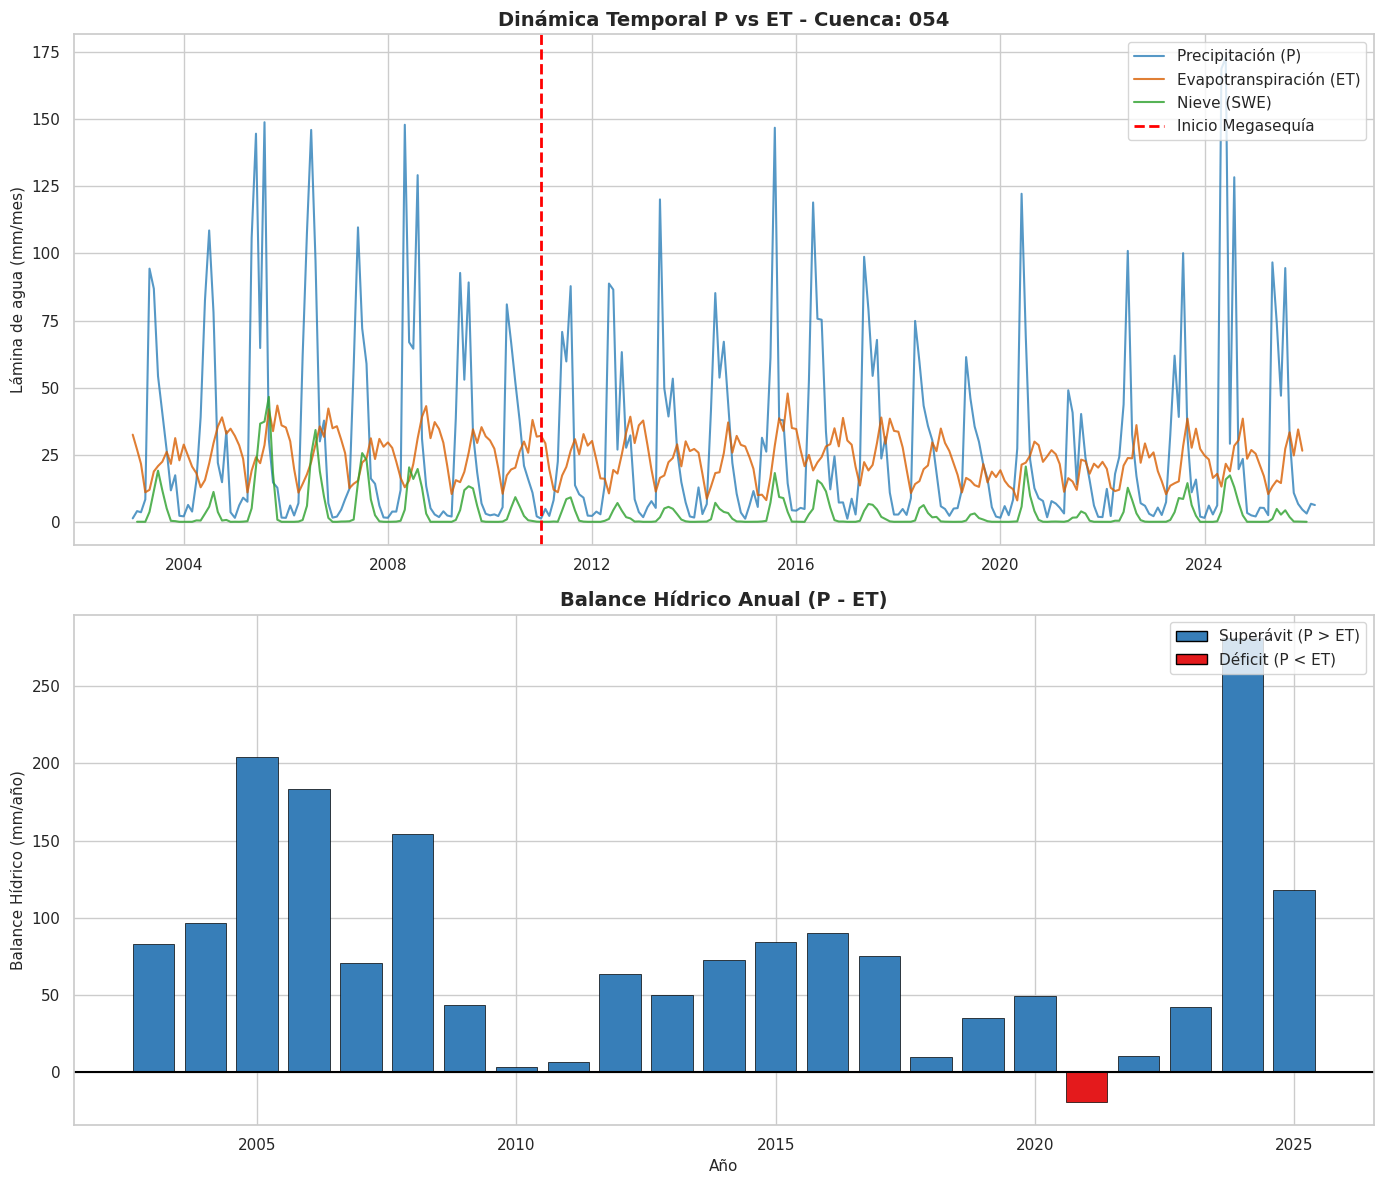

In [ ]:
# ==============================================================================
# 6. VISUALIZACIÓN TEMPORAL (Gráficos P, ET y Balance)
# ==============================================================================
print("\n[Módulo 6] Generando gráficos temporales de Balance Hídrico...")
sns.set_theme(style="whitegrid")
df_serie['Fecha_DT'] = pd.to_datetime(df_serie['Fecha'])

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# --- GRÁFICO A: Serie Histórica P y ET ---
ax1 = axes[0]
ax1.plot(df_serie['Fecha_DT'], df_serie['P_mm'], color='#2c7fb8', linewidth=1.5, label='Precipitación (P)', alpha=0.8)
ax1.plot(df_serie['Fecha_DT'], df_serie['ET_mm'], color='#d95f02', linewidth=1.5, label='Evapotranspiración (ET)', alpha=0.8)
ax1.plot(df_serie['Fecha_DT'], df_serie['SWE_tavg'], color='#2ca02c', linewidth=1.5, label='Nieve (SWE)', alpha=0.8)
ax1.axvline(pd.to_datetime('2010-12-31'), color='red', linestyle='--', linewidth=2, label='Inicio Megasequía')

ax1.set_title(f'Dinámica Temporal P vs ET - Cuenca: {cuenca_objetivo}', fontsize=14, fontweight='bold')
ax1.set_ylabel('Lámina de agua (mm/mes)', fontsize=11)
ax1.legend(loc='upper right')

# --- GRÁFICO B: Balance Hídrico Anual (Déficit / Superávit) ---
ax2 = axes[1]
# Filtramos NaNs (ej. si el año aún no tiene datos completos de ET)
df_anual_plot = df_anual.dropna(subset=['Balance_mm'])

# Asignar color según el signo del balance
colores_balance = ['#e41a1c' if b < 0 else '#377eb8' for b in df_anual_plot['Balance_mm']]

ax2.bar(df_anual_plot['a_o'], df_anual_plot['Balance_mm'], color=colores_balance, edgecolor='black', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=1.5)

ax2.set_title('Balance Hídrico Anual (P - ET)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Año', fontsize=11)
ax2.set_ylabel('Balance Hídrico (mm/año)', fontsize=11)

# Leyenda manual para el gráfico de barras
legend_elements = [Patch(facecolor='#377eb8', edgecolor='black', label='Superávit (P > ET)'),
                   Patch(facecolor='#e41a1c', edgecolor='black', label='Déficit (P < ET)')]
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
ruta_grafico_pet = f'/content/drive/MyDrive/GEOHIDRO_T4/Grafico_P_ET_{cuenca_objetivo}.png'
plt.savefig(ruta_grafico_pet, dpi=300)
print(f"- Gráfico temporal guardado en: {ruta_grafico_pet}")
plt.show()


[Módulo 8] Generando Boxplots para análisis estacional...
- Boxplot guardado en: /content/drive/MyDrive/GEOHIDRO_T4/Boxplot_054.png


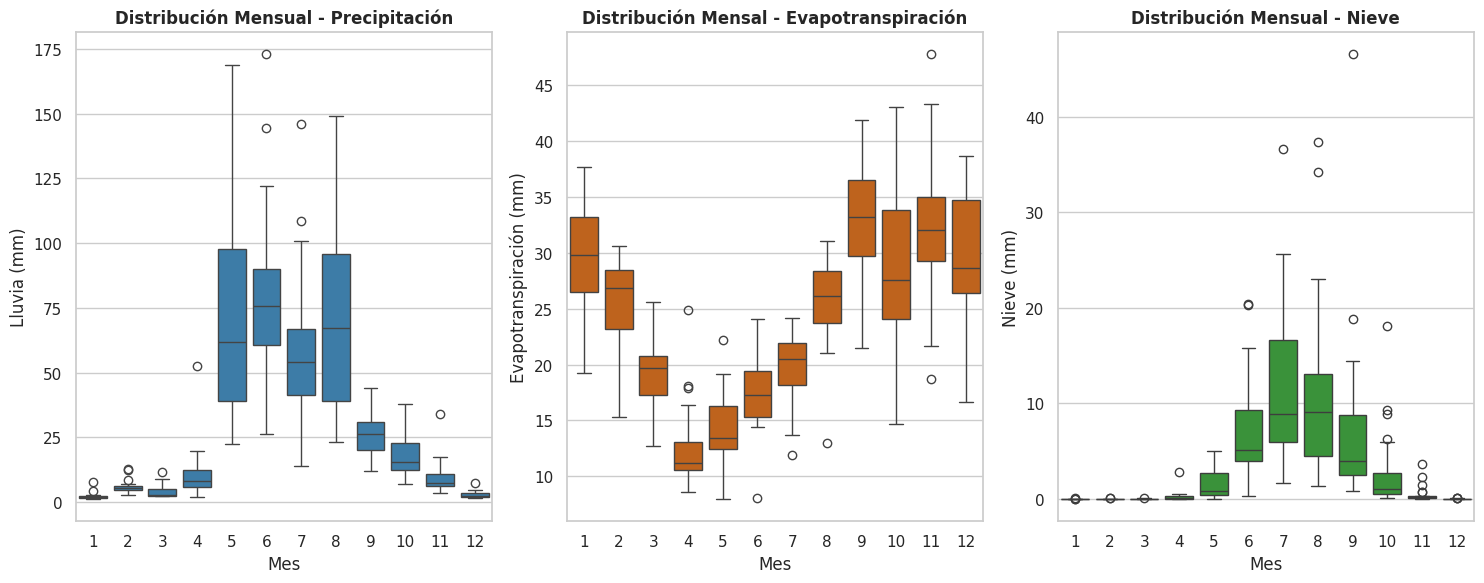

In [ ]:
# ==============================================================================
# 7. MÓDULO COMPLEMENTARIO: BOXPLOT (Distribución y valores atípicos)
# ==============================================================================
print("\n[Módulo 8] Generando Boxplots para análisis estacional...")

df_boxplot = df_serie.dropna(subset=['P_mm', 'ET_mm', 'SWE_tavg']).copy()

# Se calculan los valores atípicos (outliers) solo si la estación tiene 5 o más registros
meses_validos = df_boxplot.groupby('Mes').filter(lambda x: len(x) >= 5)

fig_box, (ax_box1, ax_box2, ax_box3) = plt.subplots(1, 3, figsize=(15, 6))

sns.boxplot(data=meses_validos, x='Mes', y='P_mm', ax=ax_box1, color='#2c7fb8')
ax_box1.set_title('Distribución Mensual - Precipitación', fontweight='bold')
ax_box1.set_ylabel('Lluvia (mm)')

sns.boxplot(data=meses_validos, x='Mes', y='ET_mm', ax=ax_box2, color='#d95f02')
ax_box2.set_title('Distribución Mensal - Evapotranspiración', fontweight='bold')
ax_box2.set_ylabel('Evapotranspiración (mm)')

sns.boxplot(data=meses_validos, x='Mes', y='SWE_tavg', ax=ax_box3, color='#2ca02c')
ax_box3.set_title('Distribución Mensual - Nieve', fontweight='bold')
ax_box3.set_ylabel('Nieve (mm)')

plt.tight_layout()
ruta_boxplot = f'/content/drive/MyDrive/GEOHIDRO_T4/Boxplot_{cuenca_objetivo}.png'
plt.savefig(ruta_boxplot, dpi=300)
print(f"- Boxplot guardado en: {ruta_boxplot}")
plt.show()

In [ ]:
# ==============================================================================
# 8A. MÓDULO COMPLEMENTARIO: EXPORTACIÓN ASÍNCRONA A GOOGLE DRIVE (TIFs)
# Objetivo: Evitar Timeouts procesando las reducciones masivas en segundo plano.
# ==============================================================================
import time
import ee

print("\n[Módulo 8A] Iniciando procesamiento en batch hacia Google Drive...")

mean_annual_end_year = 2024
num_anos_completos_mean = mean_annual_end_year - a_o_inicio + 1
rango_ini_mean = f'{a_o_inicio}-01-01'
rango_fin_mean = f'{mean_annual_end_year}-12-31'

# 1. Cálculos de reducción espacial y temporal
p_mean_annual = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY") \
                  .filterDate(rango_ini_mean, rango_fin_mean) \
                  .sum().divide(num_anos_completos_mean)

et_mean_annual = ee.ImageCollection("MODIS/061/MOD16A2GF") \
                   .filterDate(rango_ini_mean, rango_fin_mean) \
                   .select('ET').sum().multiply(0.1).divide(num_anos_completos_mean)

sw_mean_annual = ee.ImageCollection("NASA/GLDAS/V022/CLSM/G025/DA1D") \
                   .filterDate(rango_ini_mean, rango_fin_mean) \
                   .select('SWE_tavg').sum().divide(num_anos_completos_mean)

img_balance = p_mean_annual.subtract(et_mean_annual)

# 2. Función robusta de exportación con control de NoData
def exportar_tif_drive(imagen, nombre, scale=1000):
    bounds = geom_aoi.bounds().coordinates().get(0).getInfo()

    # Asignamos un valor nulo conocido (-9999) a los píxeles fuera de la cuenca
    # Esto es crítico para que Matplotlib no dibuje un cuadrado de colores
    imagen_export = imagen.clip(geom_aoi).unmask(-9999)

    task = ee.batch.Export.image.toDrive(
        image=imagen_export,
        description=nombre,
        folder='GEOHIDRO_T4',
        scale=scale,
        region=bounds,
        maxPixels=1e10,
        fileFormat='GeoTIFF'
    )
    task.start()
    return task

# 3. Disparar tareas
print("Enviando tareas a los servidores de Google...")
task_p = exportar_tif_drive(p_mean_annual, f'P_Media_{cuenca_objetivo}')
task_et = exportar_tif_drive(et_mean_annual, f'ET_Media_{cuenca_objetivo}')
task_bal = exportar_tif_drive(img_balance, f'Balance_Medio_{cuenca_objetivo}')
task_sw = exportar_tif_drive(sw_mean_annual, f'SWE_Media_{cuenca_objetivo}')

tareas = [task_p, task_et, task_bal, task_sw]

# 4. Monitoreo (Polling) para evitar ejecutar la celda de plot antes de tiempo
while any(t.active() for t in tareas):
    estados = [t.status().get('state', 'UNKNOWN') for t in tareas]
    print(f"Progreso GEE: {estados} | Esperando 30 segundos...")
    time.sleep(30)

print("\n¡Exportación completada con éxito! Los archivos .tif están en tu Drive.")


[Módulo 8A] Iniciando procesamiento en batch hacia Google Drive...
Enviando tareas a los servidores de Google...
Progreso GEE: ['READY', 'READY', 'READY', 'READY'] | Esperando 30 segundos...
Progreso GEE: ['READY', 'READY', 'READY', 'READY'] | Esperando 30 segundos...
Progreso GEE: ['READY', 'READY', 'READY', 'READY'] | Esperando 30 segundos...
Progreso GEE: ['READY', 'READY', 'READY', 'READY'] | Esperando 30 segundos...
Progreso GEE: ['READY', 'READY', 'READY', 'READY'] | Esperando 30 segundos...
Progreso GEE: ['READY', 'READY', 'READY', 'READY'] | Esperando 30 segundos...
Progreso GEE: ['READY', 'READY', 'READY', 'READY'] | Esperando 30 segundos...
Progreso GEE: ['RUNNING', 'READY', 'READY', 'READY'] | Esperando 30 segundos...
Progreso GEE: ['RUNNING', 'READY', 'READY', 'READY'] | Esperando 30 segundos...
Progreso GEE: ['COMPLETED', 'COMPLETED', 'RUNNING', 'RUNNING'] | Esperando 30 segundos...
Progreso GEE: ['COMPLETED', 'COMPLETED', 'RUNNING', 'RUNNING'] | Esperando 30 segundos...



[Módulo 8B] Leyendo TIFs locales y ensamblando el panel espacial...
- Plot de mapas espaciales guardado en: /content/drive/MyDrive/GEOHIDRO_T4/Plot_3Mapas_054.png


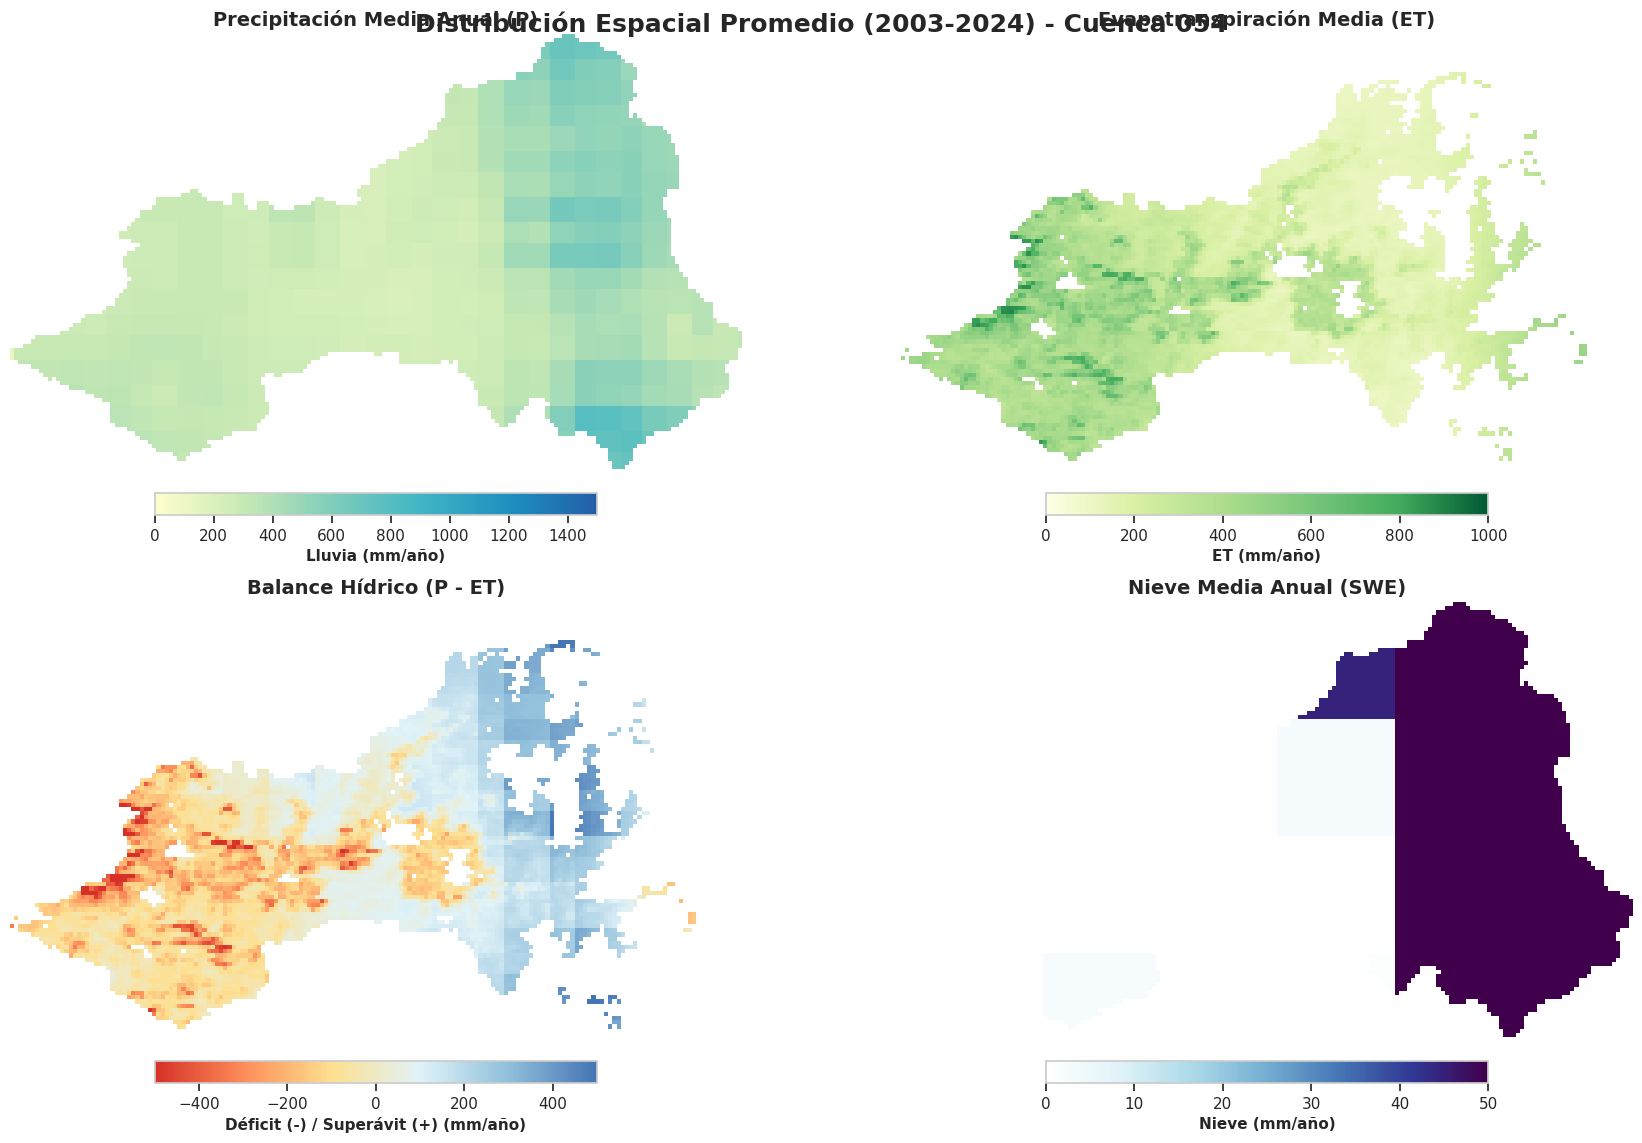

In [ ]:
# ==============================================================================
# 8B. MÓDULO COMPLEMENTARIO: LECTURA LOCAL Y PLOT MULTIPANEL ESTÁTICO
# ==============================================================================
# Instalamos rasterio silenciosamente si no está en el entorno Colab
#!pip install rasterio -q

import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os

print("\n[Módulo 8B] Leyendo TIFs locales y ensamblando el panel espacial...")

# Diccionarios visuales (con la paleta de nieve integrada)
vis_p = {'min': 0, 'max': 1500, 'palette': ['#ffffcc', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8']}
vis_et = {'min': 0, 'max': 1000, 'palette': ['#ffffe5', '#d9f0a3', '#addd8e', '#78c679', '#41ab5d', '#005a32']}
vis_bal = {'min': -500, 'max': 500, 'palette': ['#d73027', '#fc8d59', '#fee090', '#e0f3f8', '#91bfdb', '#4575b4']}
vis_swe = {'min': 0, 'max': 50, 'palette': ['#ffffff', '#e0f3f8', '#abd9e9', '#74add1', '#4575b4', '#313695', '#40004b']}

# Función para extraer matrices y enmascarar nulos
def leer_tif(ruta_archivo):
    with rasterio.open(ruta_archivo) as src:
        data = src.read(1)
        # Convertimos el NoData (-9999) en NaN para que sea transparente en el plot
        data = np.where(data == -9999, np.nan, data)
        return data

# Rutas esperadas en tu Google Drive
base_dir = '/content/drive/MyDrive/GEOHIDRO_T4'
ruta_p = os.path.join(base_dir, f'P_Media_{cuenca_objetivo}.tif')
ruta_et = os.path.join(base_dir, f'ET_Media_{cuenca_objetivo}.tif')
ruta_bal = os.path.join(base_dir, f'Balance_Medio_{cuenca_objetivo}.tif')
ruta_sw = os.path.join(base_dir, f'SWE_Media_{cuenca_objetivo}.tif')

try:
    data_p = leer_tif(ruta_p)
    data_et = leer_tif(ruta_et)
    data_bal = leer_tif(ruta_bal)
    data_sw = leer_tif(ruta_sw)
except FileNotFoundError as e:
    print(f"Error crítico: Archivo TIF no encontrado. Verifica el Módulo 8A. Detalle: {e}")
    raise

# Función adaptada para la barra de colores manejando valores NaN (fondo blanco)
def agregar_barra_color_local(ax, vis_params, titulo_leyenda):
    cmap = mcolors.LinearSegmentedColormap.from_list("custom", vis_params['palette'])
    cmap.set_bad(color='white') # Garantiza que los píxeles fuera de la cuenca no se pinten

    norm = mcolors.Normalize(vmin=vis_params['min'], vmax=vis_params['max'])
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05, fraction=0.046)
    cbar.set_label(titulo_leyenda, fontsize=11, fontweight='bold')
    return cmap, norm

# Construir la figura
fig_mapas, axs_matrix = plt.subplots(2, 2, figsize=(18, 12))
axs = axs_matrix.flatten()

# Panel 1: Precipitación
cmap_p, norm_p = agregar_barra_color_local(axs[0], vis_p, 'Lluvia (mm/año)')
axs[0].imshow(data_p, cmap=cmap_p, norm=norm_p)
axs[0].set_title('Precipitación Media Anual (P)', fontsize=14, fontweight='bold')
axs[0].axis('off')

# Panel 2: Evapotranspiración
cmap_et, norm_et = agregar_barra_color_local(axs[1], vis_et, 'ET (mm/año)')
axs[1].imshow(data_et, cmap=cmap_et, norm=norm_et)
axs[1].set_title('Evapotranspiración Media (ET)', fontsize=14, fontweight='bold')
axs[1].axis('off')

# Panel 3: Balance Hídrico
cmap_bal, norm_bal = agregar_barra_color_local(axs[2], vis_bal, 'Déficit (-) / Superávit (+) (mm/año)')
axs[2].imshow(data_bal, cmap=cmap_bal, norm=norm_bal)
axs[2].set_title('Balance Hídrico (P - ET)', fontsize=14, fontweight='bold')
axs[2].axis('off')

# Panel 4: Nieve (SWE)
cmap_sw, norm_sw = agregar_barra_color_local(axs[3], vis_swe, 'Nieve (mm/año)')
axs[3].imshow(data_sw, cmap=cmap_sw, norm=norm_sw)
axs[3].set_title('Nieve Media Anual (SWE)', fontsize=14, fontweight='bold')
axs[3].axis('off')

# Título y Ajustes finales
plt.suptitle(f'Distribución Espacial Promedio ({a_o_inicio}-{mean_annual_end_year}) - Cuenca {cuenca_objetivo}',
             fontsize=18, fontweight='bold', y=0.95)
plt.tight_layout()

ruta_plot_mapas = f'/content/drive/MyDrive/GEOHIDRO_T4/Plot_3Mapas_{cuenca_objetivo}.png'
plt.savefig(ruta_plot_mapas, dpi=300, bbox_inches='tight')
print(f"- Plot de mapas espaciales guardado en: {ruta_plot_mapas}")

plt.show()

In [ ]:
# ==============================================================================
# 9. MÓDULO COMPLEMENTARIO: MAPA INTERACTIVO (geemap)
# ==============================================================================
print("\n[Módulo 9] Renderizando mapa interactivo de la cuenca...")

mapa = geemap.Map()
mapa.centerObject(geom_aoi, zoom=10)

# Parámetros visuales (Rojo: déficit, Azul: superávit)
vis_params = {
    'min': -300,
    'max': 300,
    'palette': ['red', 'white', 'blue']
}

mapa.addLayer(img_balance.clip(geom_aoi), vis_params, 'Balance Hídrico Medio')

# Agregamos solo el borde de la cuenca para mejor visualización
borde_cuenca = ee.Image().byte().paint(featureCollection=aoi, color=1, width=2)
mapa.addLayer(borde_cuenca, {'palette': ['black']}, 'Límites de la Cuenca')

display(mapa)


[Módulo 9] Renderizando mapa interactivo de la cuenca...


In [ ]:
print("\n[Módulo 10] Renderizando mapa interactivo de Nieve (SWE)...")

# Crear el mapa base
mapa_swe = geemap.Map()
mapa_swe.centerObject(geom_aoi, zoom=10)

# Parámetros visuales para Nieve (Gradiente de azules)
vis_params_swe = {
    'min': 0,
    'max': 50,
    'palette': ['#f7fbff', '#deebf7', '#c6dbef', '#9ecae1', '#6baed6', '#2171b5', '#084594']
}

# Añadir la capa de Nieve Promedio Anual (calculada en el Módulo 8)
# Usamos nv_mean_annual que ya está definida en el estado del kernel
mapa_swe.addLayer(nv_mean_annual.clip(geom_aoi), vis_params_swe, 'Nieve Media Anual (SWE)')

# Añadir borde de la cuenca para referencia
borde_cuenca_swe = ee.Image().byte().paint(featureCollection=aoi, color=1, width=2)
mapa_swe.addLayer(borde_cuenca_swe, {'palette': ['black']}, 'Límites de la Cuenca')

display(mapa_swe)